## Kmeans:

Kmeans color only:
Silhouette Score (K-means, Color only): 0.48448999529133335
Calinski-Harabasz Index (K-means, Color only): 199780.17723252068
Kmeans color+distance:
Silhouette Score (K-means, Color + Distance): 0.3458884921969928
Calinski-Harabasz Index (K-means, Color + Distance): 98268.02393466477


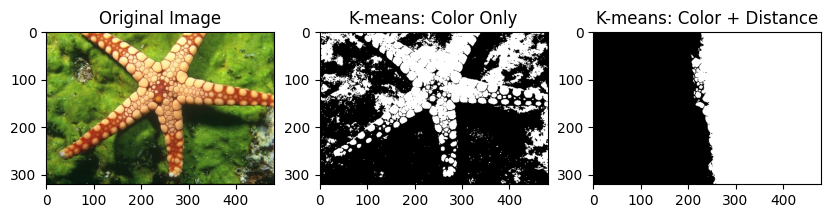

In [ ]:
import numpy as np
import cv2
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('star.jpg')  # Update with the actual file path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Reshape image for clustering
h, w, c = image_rgb.shape
coords = np.indices((h, w)).reshape(2, -1).T  # Pixel coordinates
color_features = image_rgb.reshape(-1, 3)  # RGB features
combined_features = np.hstack((color_features, coords))  # Color + distance

# K-means on color only
kmeans_color = KMeans(n_clusters=2, random_state=42).fit(color_features)
segmented_color = kmeans_color.labels_.reshape(h, w)

# K-means on color + distance
kmeans_combined = KMeans(n_clusters=2, random_state=42).fit(combined_features)
segmented_combined = kmeans_combined.labels_.reshape(h, w)

# Evaluate K-means (color only)
print("Kmeans color only:")
silhouettec = silhouette_score(color_features, kmeans_color.labels_)
calinski_harabaszc = calinski_harabasz_score(color_features, kmeans_color.labels_)

print("Silhouette Score (K-means, Color only):", silhouettec)
print("Calinski-Harabasz Index (K-means, Color only):", calinski_harabaszc)

# Evaluate K-means (color + distance example)
print("Kmeans color+distance:")
silhouette = silhouette_score(combined_features, kmeans_combined.labels_)
calinski_harabasz = calinski_harabasz_score(combined_features, kmeans_combined.labels_)

print("Silhouette Score (K-means, Color + Distance):", silhouette)
print("Calinski-Harabasz Index (K-means, Color + Distance):", calinski_harabasz)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(segmented_color, cmap='gray')
plt.title("K-means: Color Only")

plt.subplot(1, 3, 3)
plt.imshow(segmented_combined, cmap='gray')
plt.title("K-means: Color + Distance")
plt.show()


Agglomerative Clustering color only:
Silhouette Score (Agglomerative Clustering, Color only): 0.4314515842311233
Calinski-Harabasz Index (Agglomerative Clustering, Color only): 40909.448115776846
Agglomerative Clustering color+distance:
Silhouette Score (Agglomerative Clustering, Color + Distance): 0.2630768525657428
Calinski-Harabasz Index (Agglomerative Clustering, Color + Distance): 15900.851821664377


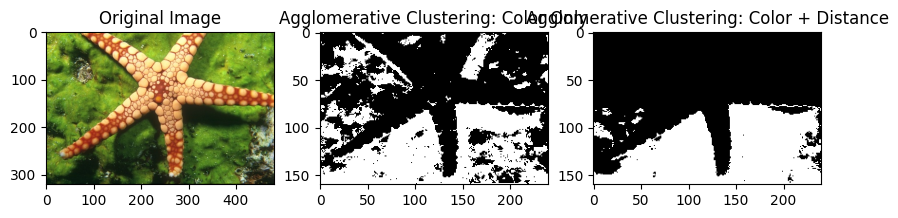

In [ ]:
h, w, c = image_rgb.shape
downscaled_image = cv2.resize(image_rgb, (w // 2, h // 2))

# Reshape image for clustering
h, w, c = downscaled_image.shape
coords = np.indices((h, w)).reshape(2, -1).T  # Pixel coordinates
color_features = downscaled_image.reshape(-1, 3)  # RGB features
combined_features = np.hstack((color_features, coords))  # Color + distance

# Agglomerative Clustering on color only
agglom_color = AgglomerativeClustering(n_clusters=2).fit(color_features)
segmented_color_agg = agglom_color.labels_.reshape(h, w)

# Agglomerative Clustering on color + distance
agglom_combined = AgglomerativeClustering(n_clusters=2).fit(combined_features)
segmented_combined_agg = agglom_combined.labels_.reshape(h, w)

# Evaluate K-means (color only)
print("Agglomerative Clustering color only:")
silhouettec = silhouette_score(color_features, agglom_color.labels_)
calinski_harabaszc = calinski_harabasz_score(color_features, agglom_color.labels_)

print("Silhouette Score (Agglomerative Clustering, Color only):", silhouettec)
print("Calinski-Harabasz Index (Agglomerative Clustering, Color only):", calinski_harabaszc)

# Evaluate K-means (color + distance example)
print("Agglomerative Clustering color+distance:")
silhouette = silhouette_score(combined_features, agglom_combined.labels_)
calinski_harabasz = calinski_harabasz_score(combined_features, agglom_combined.labels_)

print("Silhouette Score (Agglomerative Clustering, Color + Distance):", silhouette)
print("Calinski-Harabasz Index (Agglomerative Clustering, Color + Distance):", calinski_harabasz)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(segmented_color_agg, cmap='gray')
plt.title("Agglomerative Clustering: Color Only")

plt.subplot(1, 3, 3)
plt.imshow(segmented_combined_agg, cmap='gray')
plt.title("Agglomerative Clustering: Color + Distance")
plt.show()

## DBSCAN:

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN

# Load the data
data = pd.read_csv('Data.csv', header=None, names=['x', 'y', 'class'])

# Extract features and class
X = data[['x', 'y']].values
y_class = data['class'].values

# Step 1: Visualize data by class
plt.figure(figsize=(8, 6))
for cls in np.unique(y_class):
    plt.scatter(data[data['class'] == cls]['x'], data[data['class'] == cls]['y'], label=f'Class {cls}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original Data with Classes')
plt.legend()
plt.show()

# Step 2: Apply DBSCAN
eps = 0.5  # Adjust as needed
min_samples = 5  # Adjust as needed
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X)

# Separate clusters and outliers
outliers = X[labels == -1]
clusters = X[labels != -1]

# Step 3: Visualize DBSCAN results
plt.figure(figsize=(8, 6))
plt.scatter(clusters[:, 0], clusters[:, 1], c='blue', label='Cluster Points')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', label='Outliers')
plt.xlabel('x')
plt.ylabel('y')
plt.title('DBSCAN Clustering (Outliers in Red)')
plt.legend()
plt.show()


## P-DBSCAN:

## Algoritm 1:

In [35]:
import numpy as np
from collections import deque

def p_dbscan1(dataset, epsilon, min_owners, adaptive_density=False, density_drop_threshold=0.5):
    cluster_id = 0
    clusters = {}
    noise = []
    processed = set()

    def euclidean_distance(point1, point2):
        return np.sqrt(np.sum((point1[:2] - point2[:2]) ** 2))

    def get_neighborhood(point, dataset, epsilon):
        return [idx for idx, other_point in enumerate(dataset)
            if euclidean_distance(point, other_point) <= epsilon and point[2] != other_point[2]]

    for idx, point in enumerate(dataset):
        if idx in processed:
            continue

        neighborhood = get_neighborhood(point, dataset, epsilon)
        if len(set(dataset[n][2] for n in neighborhood)) < min_owners:
            noise.append(idx)
        else:
            cluster_id += 1
            clusters[cluster_id] = []
            queue = deque(neighborhood)

            while queue:
                current = queue.popleft()
                if current in processed:
                    continue
                processed.add(current)
                clusters[cluster_id].append(current)
                current_neighborhood = get_neighborhood(dataset[current], dataset, epsilon)
                if len(set(dataset[n][2] for n in current_neighborhood)) >= min_owners:
                    if adaptive_density:
                        current_density = len(current_neighborhood)
                        previous_density = len(get_neighborhood(dataset[queue[0]], dataset, epsilon)) if queue else 1
                        if current_density / previous_density > density_drop_threshold:
                            queue.extend(current_neighborhood)
                    else:
                        queue.extend(current_neighborhood)
    return clusters, noise


## Testing:

In [36]:
dataset = np.array([
    [1.0, 1.0, 1], [1.1, 1.1, 1], [2.0, 2.0, 2],
    [8.0, 8.0, 3], [8.1, 8.1, 3], [9.0, 9.0, 4]
])
epsilon = 3.0
min_owners = 1
density_drop_threshold = 0.7

clusters, noise = p_dbscan1(dataset, epsilon, min_owners, adaptive_density=True, density_drop_threshold=density_drop_threshold)
print("Clusters:", clusters)
print("Noise:", noise)


Clusters: {1: [2, 0, 1], 2: [5, 3, 4]}
Noise: []


## Algoritm 2: (Updated version of adaptive density)

In [47]:
import numpy as np
from collections import deque

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1[:2] - point2[:2]) ** 2))

def get_neighborhood(point_idx, dataset, epsilon):
    point = dataset[point_idx]
    return [idx for idx, other_point in enumerate(dataset) if euclidean_distance(point, other_point) <= epsilon and point[2] != other_point[2]]

def adaptive_density_processing(point_idx, current_density, queue, dataset, epsilon, density_drop_threshold, processed):

    # Compute neighborhood for the current point
    neighborhood = get_neighborhood(point_idx, dataset, epsilon)
    neighborhood_density = len(neighborhood)  # Number of points in the neighborhood
    # Calculate density drop
    density_drop = neighborhood_density / current_density if current_density > 0 else 0
    if neighborhood_density < current_density:
        if density_drop >= density_drop_threshold:
            current_density = neighborhood_density
            queue.extend(n for n in neighborhood if n not in processed and n not in queue)
    else:
        current_density = neighborhood_density
        queue.extend(n for n in neighborhood if n not in processed and n not in queue)

    return current_density


def p_dbscan2(dataset, epsilon, min_owners, density_drop_threshold=0.5):
    cluster_id = 0
    clusters = {}
    noise = []
    processed = set()
    queue = deque()

    def get_neighborhood(point_idx, dataset, epsilon):
        point = dataset[point_idx]
        return [idx for idx, other_point in enumerate(dataset)
            if np.linalg.norm(point[:2] - other_point[:2]) <= epsilon and point[2] != other_point[2]]

    for idx, point in enumerate(dataset):
        if idx in processed:
            continue

        neighborhood = get_neighborhood(idx, dataset, epsilon)

        if len(set(dataset[n][2] for n in neighborhood)) < min_owners:
            noise.append(idx)
        else:
            cluster_id += 1
            clusters[cluster_id] = []
            queue = deque(neighborhood)
            processed.add(idx)
            clusters[cluster_id].append(idx)

            current_density = len(neighborhood)

            while queue:
                current = queue.popleft()
                if current in processed:
                    continue

                processed.add(current)
                clusters[cluster_id].append(current)

                current_neighborhood = get_neighborhood(current, dataset, epsilon)

                if len(set(dataset[n][2] for n in current_neighborhood)) >= min_owners:
                    current_density = adaptive_density_processing(current, current_density, queue, dataset, epsilon, density_drop_threshold,processed)
    return clusters, noise


## Testing:

In [49]:
dataset = np.array([
    [1.0, 1.0, 1], [1.1, 1.1, 1], [2.0, 2.0, 2],
    [8.0, 8.0, 3], [8.1, 8.1, 3], [9.0, 9.0, 4]
])
epsilon = 3.0
min_owners = 1
density_drop_threshold = 0.5

clusters, noise = p_dbscan2(dataset, epsilon, min_owners, density_drop_threshold=density_drop_threshold)
print("Clusters:", clusters)
print("Noise:", noise)

Clusters: {1: [0, 2, 1], 2: [3, 5, 4]}
Noise: []


## Kaggle - FIFA 20: Kaggle Notebook.